In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [10]:
from google.colab import files

uploaded = files.upload()

Saving customer_retail csv file.csv to customer_retail csv file.csv


In [12]:
df = pd.read_csv("customer_retail csv file.csv")

print(df.head())
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  
(541909, 8)


In [13]:
df.dropna(inplace=True)

print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [14]:
df = df[['Quantity', 'UnitPrice', 'Country']]

print(df.head())

   Quantity  UnitPrice         Country
0         6       2.55  United Kingdom
1         6       3.39  United Kingdom
2         8       2.75  United Kingdom
3         6       3.39  United Kingdom
4         6       3.39  United Kingdom


In [15]:
df['PurchaseType'] = np.where(df['Quantity'] > 10, 1, 0)

print(df.head())

   Quantity  UnitPrice         Country  PurchaseType
0         6       2.55  United Kingdom             0
1         6       3.39  United Kingdom             0
2         8       2.75  United Kingdom             0
3         6       3.39  United Kingdom             0
4         6       3.39  United Kingdom             0


In [18]:
encoder = LabelEncoder()

df['Country'] = encoder.fit_transform(df['Country'])

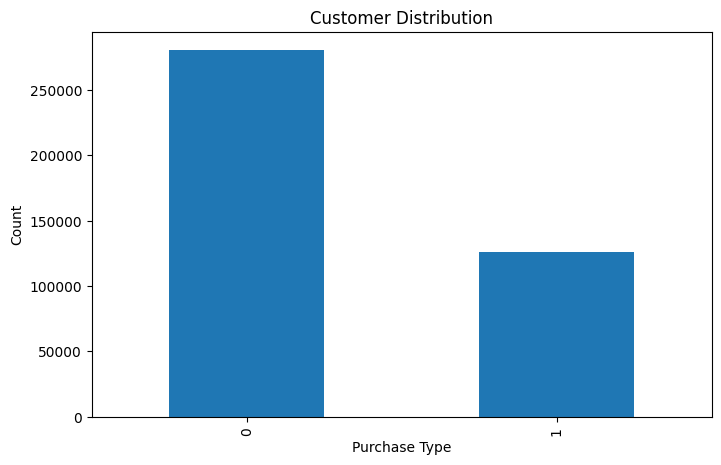

In [19]:
plt.figure(figsize=(8,5))

df['PurchaseType'].value_counts().plot(kind='bar')

plt.title("Customer Distribution")
plt.xlabel("Purchase Type")
plt.ylabel("Count")

plt.show()

In [20]:
X = df[['Quantity', 'UnitPrice', 'Country']]
y = df['PurchaseType']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)
print(confusion_matrix(y_test, lr_pred))

Logistic Regression Accuracy: 1.0
[[56047     0]
 [    0 25319]]


In [23]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 1.0
[[56047     0]
 [    0 25319]]


In [24]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)
print(confusion_matrix(y_test, knn_pred))

KNN Accuracy: 0.9999631295627166
[[56047     0]
 [    3 25316]]


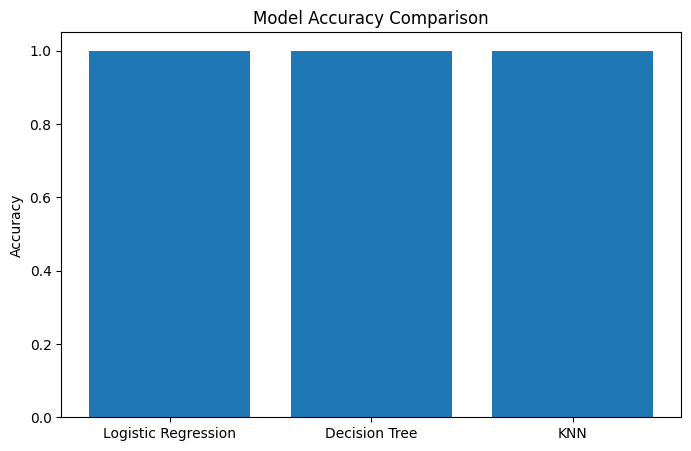

In [27]:
models = [
    "Logistic Regression",
    "Decision Tree",
    "KNN"
]

accuracies = [
    lr_acc,
    dt_acc,
    knn_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [28]:
print("Logistic Regression Accuracy :", lr_acc)
print("Decision Tree Accuracy :", dt_acc)
print("KNN Accuracy :", knn_acc)

best_model = max(
    {
        "Logistic Regression": lr_acc,
        "Decision Tree": dt_acc,
        "KNN": knn_acc
    },
    key=lambda x: {
        "Logistic Regression": lr_acc,
        "Decision Tree": dt_acc,
        "KNN": knn_acc
    }[x]
)

print("\nBest Model:", best_model)

Logistic Regression Accuracy : 1.0
Decision Tree Accuracy : 1.0
KNN Accuracy : 0.9999631295627166

Best Model: Logistic Regression
